# MahmoodLab CONCH — Histopathology Vision-Language Model Test

This notebook verifies the HuggingFace `MahmoodLab/CONCH` model (CONtrastive learning from Captions for Histopathology) runs on Apple Silicon (`mps`).

CONCH is a **contrastive** vision-language model (CLIP-style) trained on 1.17 million histopathology image-caption pairs. Unlike generative models such as CheXagent, CONCH produces **dense embeddings** — it does not write free-text reports. Its primary tasks are:

- **Zero-shot classification** — rank a set of tissue/disease candidate labels against an image by cosine similarity.
- **Image–text similarity** — score how closely a known caption matches its paired image.

**Domain:** Computational Pathology (H&E, IHC, optical microscopy).  
**Architecture:** ViT-B/16 image encoder + PubMedBERT-based text encoder, jointly trained with contrastive loss.  
**Paper:** [CONCH (Lu et al., Nature Medicine 2024)](https://www.nature.com/articles/s41591-024-02856-4)  
**HuggingFace:** `MahmoodLab/CONCH` (requires accepted terms of use + HF token)

### CONCH vs CheXagent — Key Differences

| Aspect | CONCH | CheXagent-2-3b |
|---|---|---|
| Model type | Contrastive (CLIP-style) | Generative (VLM) |
| Output | Embedding vector | Free-text report |
| Domain | Histopathology | Chest radiology |
| Task | Classification / retrieval | Report generation |
| Suitable datasets | Quilt1M, PKG HSI-GB | IQ-OTH NCCD, Spinal DICOM |

### Supported tasks in this notebook
1. **Zero-shot classification** — score each histopathology image against tissue/disease categories extracted from the Quilt1M CSV metadata.
2. **Image–text similarity** — compare each image embedding against its ground-truth caption from the CSV to validate alignment.

In [3]:
import warnings
import logging

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
logging.getLogger("transformers").setLevel(logging.ERROR)

# protobuf >= 4.21 compatibility patch
try:
    from google.protobuf import message_factory as _mf, symbol_database as _sd
    if not hasattr(_mf.MessageFactory, "GetPrototype"):
        def _get_prototype(self, descriptor):
            return _sd.Default().GetSymbol(descriptor.full_name)
        _mf.MessageFactory.GetPrototype = _get_prototype
except Exception:
    pass

In [4]:
import ast
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image

from conch.open_clip_custom import create_model_from_pretrained, get_tokenizer, tokenize

# Device setup — CONCH uses float32; MPS is supported
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


In [5]:
# Load CONCH model and image preprocessor
# First run downloads ~350 MB of weights from HuggingFace Hub.
# Requires HF_TOKEN env var (model is gated — must accept terms at hf.co/MahmoodLab/conch).
HF_TOKEN = os.environ.get("HF_TOKEN")

model, preprocess = create_model_from_pretrained(
    "conch_ViT-B-16",
    "hf_hub:MahmoodLab/conch",
    hf_auth_token=HF_TOKEN,
)
model = model.to(device)
model.eval()

tokenizer = get_tokenizer()

print("CONCH model loaded successfully.")
print(f"  Image encoder: ViT-B/16  |  Input size: 448×448")
print(f"  Text encoder : PubMedBERT-based")

meta.yaml:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/802M [00:00<?, ?B/s]

CONCH model loaded successfully.
  Image encoder: ViT-B/16  |  Input size: 448×448
  Text encoder : PubMedBERT-based


## Zero-shot Classification Labels

We derive candidate tissue/disease labels from the `pathology` column of `quilt_1M_lookup.csv`.
Each cell contains a list of pathology sub-specialties (e.g., `['Dermatopathology', 'Soft tissue', 'Breast']`).
We parse all lists, collect unique values, and sort them alphabetically.

In [6]:
CSV_PATH = Path("../week1/data/quilt_1M_lookup.csv")

df_quilt = pd.read_csv(CSV_PATH, low_memory=False)

def parse_pathology_list(val) -> list[str]:
    """Parse a stringified Python list or return [] for nulls."""
    if pd.isna(val) or str(val).strip() in ("", "nan", "[]"):
        return []
    try:
        parsed = ast.literal_eval(str(val))
        return [s.strip() for s in parsed if isinstance(s, str) and s.strip()]
    except (ValueError, SyntaxError):
        return []

all_categories: list[str] = sorted(
    set(
        cat
        for cats in df_quilt["pathology"].apply(parse_pathology_list)
        for cat in cats
    )
)

print(f"Loaded {len(df_quilt):,} rows from quilt_1M_lookup.csv")
print(f"Unique pathology categories: {len(all_categories)}")
print("\nAll categories:")
for i, cat in enumerate(all_categories, 1):
    print(f"  {i:>3}. {cat}")

Loaded 100 rows from quilt_1M_lookup.csv
Unique pathology categories: 18

All categories:
    1. Bone
    2. Breast
    3. Cardiac
    4. Cytopathology
    5. Dermatopathology
    6. Endocrine
    7. Gastrointestinal
    8. Genitourinary
    9. Gynecologic
   10. Head and Neck
   11. Hematopathology
   12. Neuropathology
   13. Ophthalmic
   14. Others
   15. Pediatric
   16. Pulmonary
   17. Renal
   18. Soft tissue


## Helper Functions

- `encode_image` — preprocess a PIL image and run the CONCH image encoder.
- `encode_texts` — tokenize a list of strings and run the CONCH text encoder.
- `zero_shot_classify` — rank candidate labels by softmax similarity (same as CLIP zero-shot).
- `image_text_similarity` — compute raw cosine similarity between a single image and a single caption.

In [7]:
# CONCH zero-shot prompt template (from the original paper)
PROMPT_TEMPLATE = "an H&E stained histopathology image of {}"


def encode_image(pil_img: Image.Image) -> torch.Tensor:
    """Return a normalised image embedding of shape (1, D)."""
    tensor = preprocess(pil_img.convert("RGB")).unsqueeze(0).to(device)
    with torch.inference_mode():
        emb = model.encode_image(tensor, normalize=True)
    return emb  # (1, D)


def encode_texts(texts: list[str]) -> torch.Tensor:
    """Return normalised text embeddings of shape (N, D)."""
    tokens = tokenize(tokenizer=tokenizer, texts=texts).to(device)
    with torch.inference_mode():
        embs = model.encode_text(tokens, normalize=True)
    return embs  # (N, D)


def zero_shot_classify(
    image_emb: torch.Tensor,
    categories: list[str],
    top_k: int = 5,
) -> list[tuple[str, float]]:
    """
    Rank `categories` against `image_emb` using softmax-scaled cosine similarity.
    Returns top_k (label, probability) pairs sorted descending.
    """
    prompts = [PROMPT_TEMPLATE.format(c) for c in categories]
    text_embs = encode_texts(prompts)  # (N, D)
    # Logit scale = 100.0, matching standard CLIP/CONCH practice
    logits = (100.0 * image_emb @ text_embs.T).softmax(dim=-1)  # (1, N)
    probs = logits[0].cpu().numpy()
    ranked = sorted(zip(categories, probs.tolist()), key=lambda x: x[1], reverse=True)
    return ranked[:top_k]


def image_text_similarity(image_emb: torch.Tensor, caption: str) -> float:
    """
    Cosine similarity between image embedding and a single caption.
    Both embeddings are already L2-normalised, so dot product = cosine similarity.
    """
    caption_emb = encode_texts([caption])  # (1, D)
    sim = (image_emb * caption_emb).sum().item()
    return round(sim, 4)


print("Helper functions defined.")
print(f"Zero-shot prompt template: '{PROMPT_TEMPLATE}'")

Helper functions defined.
Zero-shot prompt template: 'an H&E stained histopathology image of {}'


## Local Dataset Samples

We test CONCH on the five histopathology samples from `week1/data`:

| Sample | Dataset | Subset | Notes |
|---|---|---|---|
| `c901a42b…_1.jpg` | Quilt1M | pubmed | IDH1 immunocytochemistry, osteosarcoma |
| `dTr3MNl1…jpg` | Quilt1M | quilt (YouTube) | Nephrogenic systemic fibrosis |
| `9947014…_0.jpg` | Quilt1M | openpath (Twitter) | Peritoneal biopsy |
| `0000400…jpg` | Quilt1M | laion | Web-scraped histopathology |
| `P1.png` | PKG HistologyHSI-GB | — | Glioblastoma RGB thumbnail |

For each sample we:
1. Display the image.
2. Run **zero-shot classification** over all CSV-derived categories (top-5).
3. For Quilt1M samples: compute **image–text similarity** against the ground-truth CSV caption.

In [8]:
BASE_DATA_DIR = Path("../week1/data")

LOCAL_SAMPLES = [
    {
        "name": "Quilt1M — PubMed",
        "path": BASE_DATA_DIR / "Quilt1M_pubmed" / "c901a42b-0ab9-45d9-809d-dd646effcf9c_1.jpg",
        "image_filename": "c901a42b-0ab9-45d9-809d-dd646effcf9c_1.jpg",
    },
    {
        "name": "Quilt1M — YouTube (quilt)",
        "path": BASE_DATA_DIR / "Quilt1M_quilt" / "dTr3MNl1FxE_image_c54e9a8d-9348-456a-9645-3b8921eb0b79.jpg",
        "image_filename": "dTr3MNl1FxE_image_c54e9a8d-9348-456a-9645-3b8921eb0b79.jpg",
    },
    {
        "name": "Quilt1M — OpenPath (Twitter)",
        "path": BASE_DATA_DIR / "Quilt1M_openpath" / "994701482116173824_0.jpg",
        "image_filename": "994701482116173824_0.jpg",
    },
    {
        "name": "Quilt1M — LAION",
        "path": BASE_DATA_DIR / "Quilt1M_laion" / "00004000040081.jpg",
        "image_filename": "00004000040081.jpg",
    },
    {
        "name": "PKG HistologyHSI-GB — P1 (RGB thumbnail)",
        "path": BASE_DATA_DIR / "PKG_HistologyHSI_GB" / "P1" / "P1.png",
        "image_filename": None,  # not in Quilt1M CSV
    },
]


def get_csv_meta(image_filename: str | None) -> dict:
    """Return CSV row dict for this filename, or {} if not in CSV."""
    if image_filename is None:
        return {}
    matches = df_quilt[df_quilt["image_path"] == image_filename]
    if matches.empty:
        return {}
    row = matches.iloc[0].to_dict()
    return {k: (None if (isinstance(v, float) and np.isnan(v)) else v) for k, v in row.items()}


print(f"Defined {len(LOCAL_SAMPLES)} local samples for CONCH evaluation.")

Defined 5 local samples for CONCH evaluation.



  Sample : Quilt1M — PubMed
  Path   : c901a42b-0ab9-45d9-809d-dd646effcf9c_1.jpg
  Caption    : The immunocytochemistry of IDH1 in MG63 and U2OS. IDH1 is specifically detected in the cytoplasm of both osteosarcoma ce
  Pathology  : —
  Subset     : pubmed  |  Magnification: —

  [TASK 1] Zero-shot classification (top-5):
    1. Breast                          80.71%  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
    2. Soft tissue                     19.28%  █████████████████████████████████████████████████████████████████████████████
    3. Genitourinary                    0.01%  
    4. Head and Neck                    0.00%  
    5. Others                           0.00%  

  [TASK 2] Image–caption cosine sim

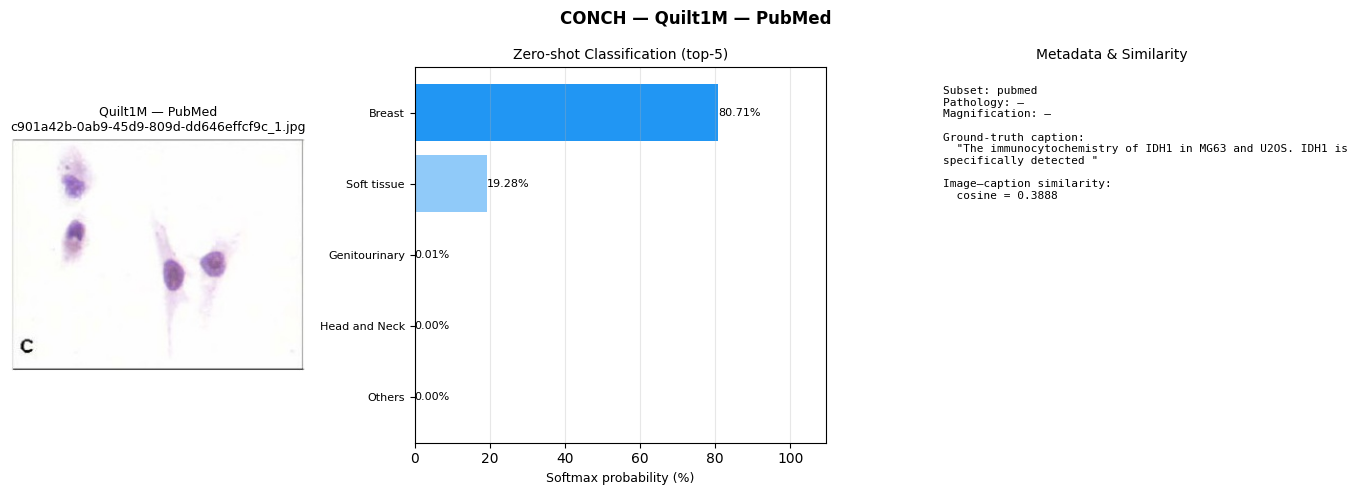


  Sample : Quilt1M — YouTube (quilt)
  Path   : dTr3MNl1FxE_image_c54e9a8d-9348-456a-9645-3b8921eb0b79.jpg
  Caption    : Nephrogenic systemic fibrosis is a fibrotic disorder with deep involvement that goes down to the fascia.
  Pathology  : ['Dermatopathology', 'Soft tissue', 'Breast']
  Subset     : quilt  |  Magnification: —

  [TASK 1] Zero-shot classification (top-5):
    1. Breast                          100.00%  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
    2. Genitourinary                    0.00%  
    3. Dermatopathology                 0.00%  
    4. Head and Neck                    0.00%  
    5. Hematopathology         

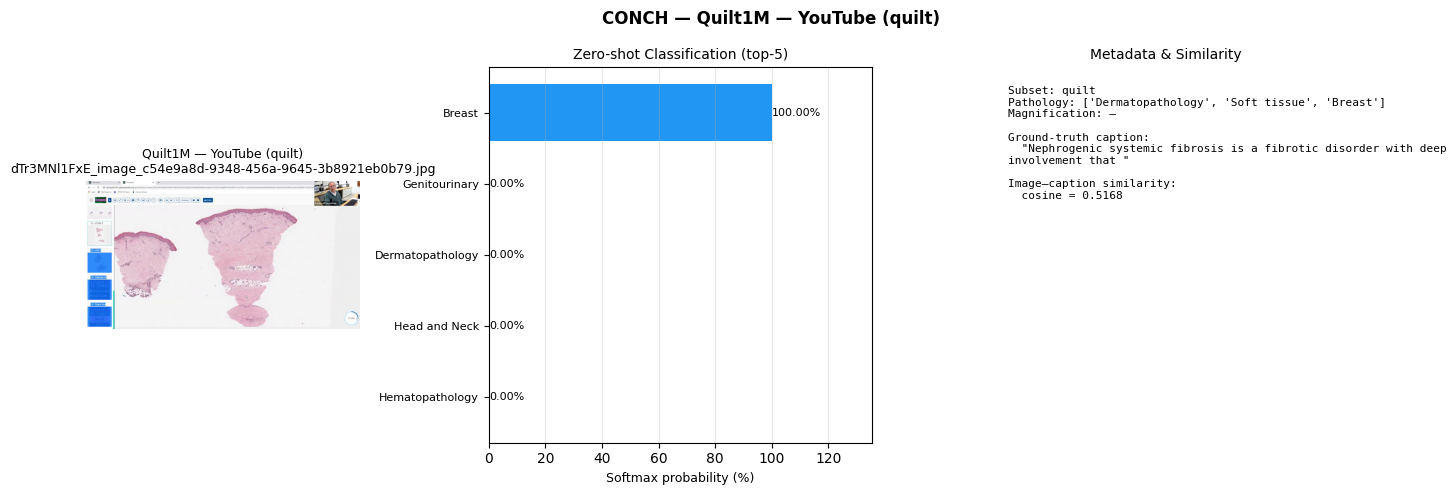


  Sample : Quilt1M — OpenPath (Twitter)
  Path   : 994701482116173824_0.jpg
  Caption    : Peritoneum, Day 4 These two biopsies (1 & 2) were taken from the same patient. What is your DailyDx of each of these per
  Pathology  : —
  Subset     : openpath  |  Magnification: —

  [TASK 1] Zero-shot classification (top-5):
    1. Breast                          74.51%  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
    2. Gynecologic                     25.49%  █████████████████████████████████████████████████████████████████████████████████████████████████████
    3. Genitourinary                    0.00%  
    4. Others                           0.00%  
    5. Cytopathology                    0.00%  

  [TASK 2] Image–caption cosine similar

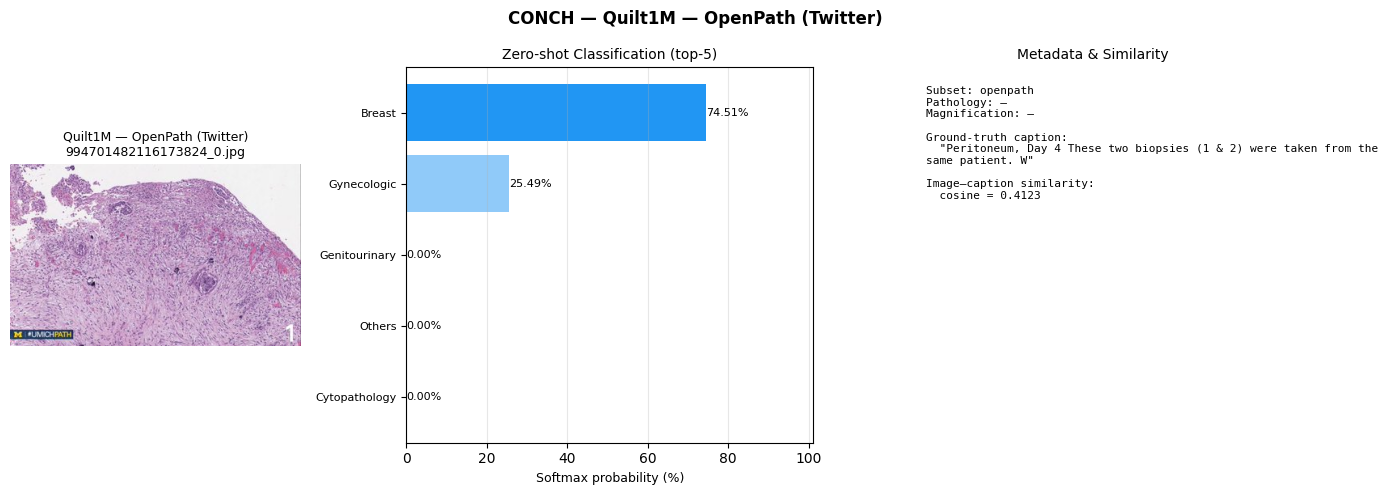


  Sample : Quilt1M — LAION
  Path   : 00004000040081.jpg
  Caption    : Cytosolic Sulfotransferase 1A1 /SULT1A1 Antibody
  Pathology  : —
  Subset     : laion  |  Magnification: —

  [TASK 1] Zero-shot classification (top-5):
    1. Endocrine                       96.44%  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
    2. Gynecologic                      3.56%  ██████████████
    3. Renal                            0.00%  
    4. Ophthalmic                       0.00%  
    5. Pulmonary                        0.00%  

  [TASK 2] Image–caption cosine similarity: 0.4146
           Caption: "Cytosolic Sulfotransferase 1A1 /SULT1A1 Antibody"


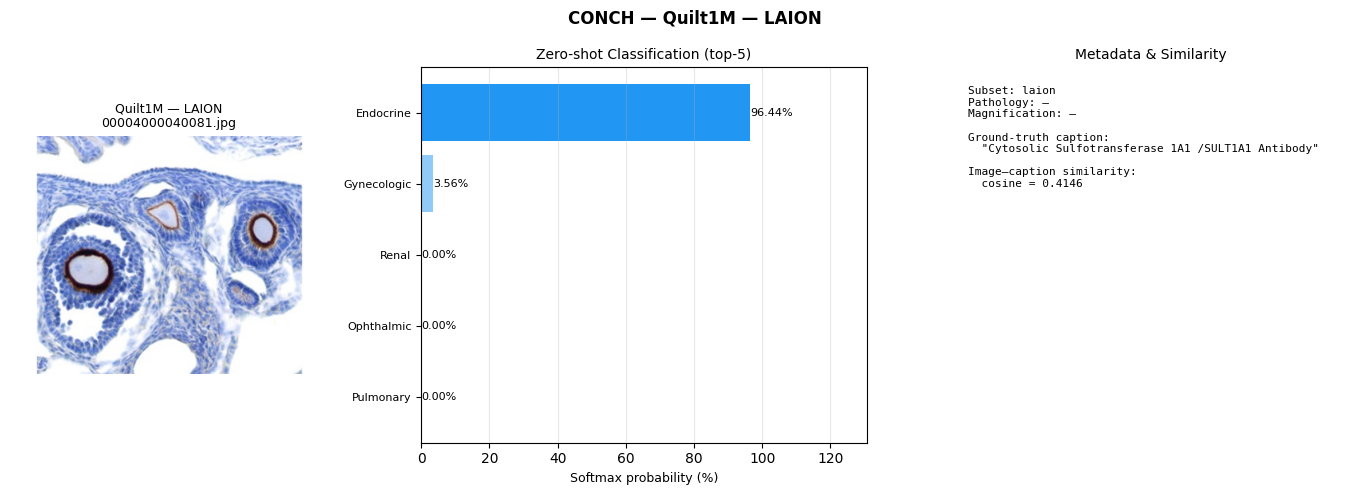


  Sample : PKG HistologyHSI-GB — P1 (RGB thumbnail)
  Path   : P1.png
  Pathology  : —
  Subset     : —  |  Magnification: —

  [TASK 1] Zero-shot classification (top-5):
    1. Neuropathology                  94.01%  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
    2. Pulmonary                        3.71%  ██████████████
    3. Genitourinary                    1.53%  ██████
    4. Gastrointestinal                 0.72%  ██
    5. Breast                           0.02%  

  [TASK 2] No ground-truth caption (PKG sample — skipped)


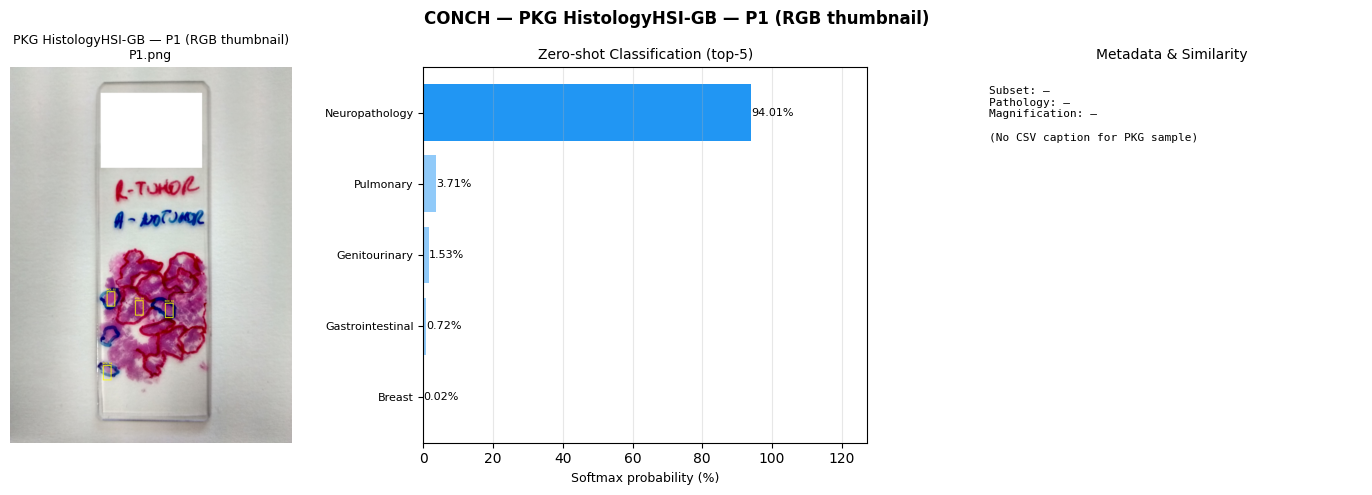

In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

RESULTS = []  # collect for summary table

for sample in LOCAL_SAMPLES:
    img_path = Path(sample["path"])
    print("\n" + "=" * 65)
    print(f"  Sample : {sample['name']}")
    print(f"  Path   : {img_path.name}")

    if not img_path.exists():
        print(f"  [ERROR] File not found: {img_path}")
        continue

    # ── Load image ──────────────────────────────────────────────────────────
    pil_img = Image.open(img_path).convert("RGB")

    # ── CSV metadata ────────────────────────────────────────────────────────
    meta = get_csv_meta(sample["image_filename"])
    caption = meta.get("caption") or ""
    pathology_str = str(meta.get("pathology") or "—")
    subset_str = str(meta.get("subset") or "—")
    magnification_str = str(meta.get("magnification") or "—")

    if caption:
        print(f"  Caption    : {caption[:120]}")
    print(f"  Pathology  : {pathology_str}")
    print(f"  Subset     : {subset_str}  |  Magnification: {magnification_str}")

    # ── Encode image ────────────────────────────────────────────────────────
    image_emb = encode_image(pil_img)

    # ── Task 1: Zero-shot classification ────────────────────────────────────
    top5 = zero_shot_classify(image_emb, all_categories, top_k=5)
    print("\n  [TASK 1] Zero-shot classification (top-5):")
    for rank, (label, prob) in enumerate(top5, 1):
        bar = "█" * int(prob * 400)
        print(f"    {rank}. {label:<30}  {prob*100:5.2f}%  {bar}")

    # ── Task 2: Image–text similarity (Quilt1M samples only) ────────────────
    similarity = None
    if caption:
        similarity = image_text_similarity(image_emb, caption)
        print(f"\n  [TASK 2] Image–caption cosine similarity: {similarity:.4f}")
        print(f"           Caption: \"{caption[:100]}\"")
    else:
        print("\n  [TASK 2] No ground-truth caption (PKG sample — skipped)")

    # ── Visualisation ───────────────────────────────────────────────────────
    fig = plt.figure(figsize=(14, 5))
    gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 1.4, 1.2])

    # Panel A: image
    ax_img = fig.add_subplot(gs[0])
    ax_img.imshow(pil_img)
    ax_img.set_title(f"{sample['name']}\n{img_path.name}", fontsize=9)
    ax_img.axis("off")

    # Panel B: zero-shot bar chart
    ax_zs = fig.add_subplot(gs[1])
    labels_plot = [t[0] for t in top5]
    probs_plot = [t[1] * 100 for t in top5]
    colours = ["#2196F3" if i == 0 else "#90CAF9" for i in range(len(top5))]
    bars = ax_zs.barh(labels_plot[::-1], probs_plot[::-1], color=colours[::-1], edgecolor="none")
    ax_zs.set_xlabel("Softmax probability (%)", fontsize=9)
    ax_zs.set_title("Zero-shot Classification (top-5)", fontsize=10)
    ax_zs.tick_params(axis="y", labelsize=8)
    for bar_obj, p in zip(bars, probs_plot[::-1]):
        ax_zs.text(bar_obj.get_width() + 0.01, bar_obj.get_y() + bar_obj.get_height() / 2,
                   f"{p:.2f}%", va="center", fontsize=8)
    ax_zs.set_xlim(0, max(probs_plot) * 1.35 + 0.5)
    ax_zs.grid(axis="x", alpha=0.3)

    # Panel C: metadata + similarity text
    ax_meta = fig.add_subplot(gs[2])
    ax_meta.axis("off")
    meta_lines = [
        f"Subset: {subset_str}",
        f"Pathology: {pathology_str[:50]}",
        f"Magnification: {magnification_str}",
        "",
    ]
    if caption:
        meta_lines += [
            "Ground-truth caption:",
            f"  \"{caption[:80]}\"",
            "",
            f"Image–caption similarity:",
            f"  cosine = {similarity:.4f}",
        ]
    else:
        meta_lines += ["(No CSV caption for PKG sample)"]

    ax_meta.text(
        0.02, 0.95,
        "\n".join(meta_lines),
        transform=ax_meta.transAxes,
        fontsize=8, verticalalignment="top", family="monospace",
        wrap=True,
    )
    ax_meta.set_title("Metadata & Similarity", fontsize=10)

    fig.suptitle(f"CONCH — {sample['name']}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    RESULTS.append({
        "sample": sample["name"],
        "top1_label": top5[0][0],
        "top1_prob_pct": round(top5[0][1] * 100, 2),
        "top2_label": top5[1][0],
        "top2_prob_pct": round(top5[1][1] * 100, 2),
        "caption_similarity": similarity,
    })

## Summary

Consolidated results across all five samples.

In [10]:
df_results = pd.DataFrame(RESULTS)

print("CONCH Evaluation Summary")
print("=" * 90)
print(f"{'Sample':<38} {'Top-1 Label':<28} {'Prob%':>6}  {'Caption Sim':>11}")
print("-" * 90)
for _, row in df_results.iterrows():
    sim_str = f"{row['caption_similarity']:.4f}" if row["caption_similarity"] is not None else "  N/A  "
    print(f"{row['sample']:<38} {row['top1_label']:<28} {row['top1_prob_pct']:>5.2f}%  {sim_str:>11}")
print("=" * 90)

quilt_sims = df_results["caption_similarity"].dropna()
if not quilt_sims.empty:
    print(f"\nMean image–caption cosine similarity (Quilt1M samples): {quilt_sims.mean():.4f}")
    print("(CONCH paper reports ~0.35–0.45 on held-out Quilt1M pairs; higher = better alignment)")

CONCH Evaluation Summary
Sample                                 Top-1 Label                   Prob%  Caption Sim
------------------------------------------------------------------------------------------
Quilt1M — PubMed                       Breast                       80.71%       0.3888
Quilt1M — YouTube (quilt)              Breast                       100.00%       0.5168
Quilt1M — OpenPath (Twitter)           Breast                       74.51%       0.4123
Quilt1M — LAION                        Endocrine                    96.44%       0.4146
PKG HistologyHSI-GB — P1 (RGB thumbnail) Neuropathology               94.01%          nan

Mean image–caption cosine similarity (Quilt1M samples): 0.4331
(CONCH paper reports ~0.35–0.45 on held-out Quilt1M pairs; higher = better alignment)
